In [1]:
import glob
import requests
from collections import defaultdict
import numpy as np
from sklearn.model_selection import train_test_split
import nibabel as nib
from scipy.ndimage.interpolation import map_coordinates
import operator
from scipy.ndimage.interpolation import shift,rotate
import scipy.ndimage as ndi
from sklearn.metrics import r2_score,mean_absolute_error
import math
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

C:\Users\aliat\AppData\Local\Temp\ipykernel_20540\2033178322.py:7: DeprecationWarning: Please import `map_coordinates` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import map_coordinates
C:\Users\aliat\AppData\Local\Temp\ipykernel_20540\2033178322.py:9: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift,rotate
C:\Users\aliat\AppData\Local\Temp\ipykernel_20540\2033178322.py:9: DeprecationWarning: Please import `rotate` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift,rotate


In [2]:
import os
import re
import glob
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import train_test_split

def getIXIData(imageType):
    # root
    ixi_t1_root = r"C:/Deep learning/Final Project/IXI-T1"

    # collect paths based on type
    paths = []

    if imageType == "RawT1":
        # original IXI-T1 style (often compressed .nii.gz)
        paths += glob.glob(os.path.join(ixi_t1_root, "**", "*T1*.nii"), recursive=True)
        paths += glob.glob(os.path.join(ixi_t1_root, "**", "*T1*.nii.gz"), recursive=True)

    # elif imageType == "GrayMatter":
    #     paths += glob.glob(os.path.join(archive_root, "**", "mwp1*.nii"), recursive=True)
    #     paths += glob.glob(os.path.join(archive_root, "**", "mwp1*.nii.gz"), recursive=True)

    # elif imageType == "WhiteMatter":
    #     paths += glob.glob(os.path.join(archive_root, "**", "mwp2*.nii"), recursive=True)
    #     paths += glob.glob(os.path.join(archive_root, "**", "mwp2*.nii.gz"), recursive=True)

    # elif imageType == "Jacobian":
    #     paths += glob.glob(os.path.join(archive_root, "**", "wj*.nii"), recursive=True)
    #     paths += glob.glob(os.path.join(archive_root, "**", "wj*.nii.gz"), recursive=True)

    else:
        raise ValueError(f"Unsupported imageType: {imageType}")

    if not paths:
        raise FileNotFoundError(f"No files found for imageType '{imageType}'")

    # map subject ID -> file paths
    idToPath = defaultdict(list)
    for p in paths:
        fname = os.path.basename(p)

        # robust ID parsing for both naming styles
        m = re.search(r"IXI(\d+)", fname, flags=re.IGNORECASE)
        if m:
            sid = m.group(1)
            idToPath[sid].append(p)

    idFrame = pd.DataFrame.from_dict(idToPath, orient="index")
    if idFrame.empty:
        raise ValueError("Parsed 0 subject IDs from filenames.")

    idFrame["ID"] = idFrame.index.astype(int)
    train, val = train_test_split(idFrame, test_size=0.2, random_state=257572)
    return train, val


In [3]:
imageType = 'RawT1'
# imageType = 'GrayMatter'
# imageType = 'WhiteMatter'
# imageType = 'Jacobian'

train_IXI, val_IXI = getIXIData(imageType)

Showing: C:/Deep learning/Final Project/IXI-T1\IXI284-HH-2354-T1.nii.gz


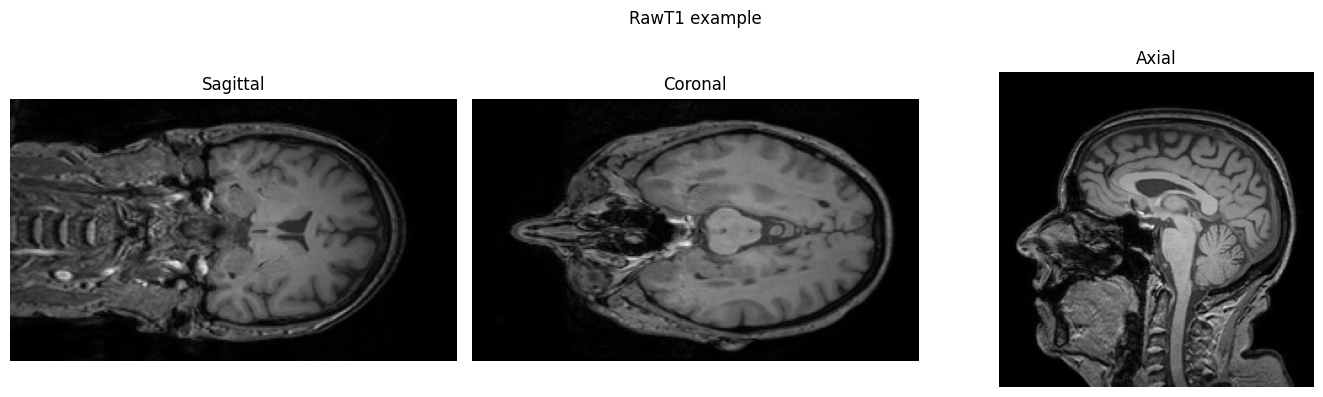

In [4]:
def _is_nii_path(v):
    return isinstance(v, str) and v.lower().endswith((".nii", ".nii.gz"))

def _pick_nii_path(row):
    for v in row.values:
        if _is_nii_path(v):
            return v
    return None

def _first_nii_in_df(df):
    for v in df.to_numpy().ravel():
        if _is_nii_path(v):
            return v
    return None

def show_nii(path, title=None):
    img = nib.load(path)
    vol = img.get_fdata()

    # middle slices
    x, y, z = [d // 2 for d in vol.shape]

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(np.rot90(vol[x, :, :]), cmap="gray")
    ax[0].set_title("Sagittal")
    ax[0].axis("off")

    ax[1].imshow(np.rot90(vol[:, y, :]), cmap="gray")
    ax[1].set_title("Coronal")
    ax[1].axis("off")

    ax[2].imshow(np.rot90(vol[:, :, z]), cmap="gray")
    ax[2].set_title("Axial")
    ax[2].axis("off")

    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()

# visualize first training sample
sample_path = _pick_nii_path(train_IXI.iloc[0])
if sample_path is None:
    sample_path = _first_nii_in_df(train_IXI)

if sample_path is None:
    raise ValueError('No .nii or .nii.gz path found in train_IXI')

print("Showing:", sample_path)
show_nii(sample_path, title=f"{imageType} example")


In [5]:
# 1) Normalize
def normalize_volume(vol, method="zscore"):
    vol = vol.astype(np.float32)
    if method == "zscore":
        m, s = vol.mean(), vol.std() + 1e-8
        return (vol - m) / s
    elif method == "minmax":
        vmin, vmax = vol.min(), vol.max()
        return (vol - vmin) / (vmax - vmin + 1e-8)
    else:
        raise ValueError("method must be 'zscore' or 'minmax'")

# 2) Random 2D slice / crop helpers
def random_slice_2d(vol, axis=2):
    # axis=0 sagittal, 1 coronal, 2 axial
    idx = np.random.randint(0, vol.shape[axis])
    return np.take(vol, idx, axis=axis)

def center_crop_or_pad_2d(img, target_hw=(128, 128)):
    th, tw = target_hw
    h, w = img.shape

    # crop if larger
    if h > th:
        top = (h - th) // 2
        img = img[top:top + th, :]
    if w > tw:
        left = (w - tw) // 2
        img = img[:, left:left + tw]

    # pad if smaller
    h, w = img.shape
    pad_h = max(0, th - h)
    pad_w = max(0, tw - w)
    if pad_h > 0 or pad_w > 0:
        img = np.pad(
            img,
            ((pad_h // 2, pad_h - pad_h // 2), (pad_w // 2, pad_w - pad_w // 2)),
            mode='constant'
        )
    return img.astype(np.float32)

# 3) Create low-resolution input (2D or 3D)
def make_low_res(hr, scale=2):
    if hr.ndim == 2:
        zoom_down = (1 / scale, 1 / scale)
        zoom_up = (scale, scale)
    elif hr.ndim == 3:
        zoom_down = (1 / scale, 1 / scale, 1 / scale)
        zoom_up = (scale, scale, scale)
    else:
        raise ValueError(f'Expected 2D or 3D input, got shape {hr.shape}')

    lr_small = ndi.zoom(hr, zoom=zoom_down, order=3)
    lr_up = ndi.zoom(lr_small, zoom=zoom_up, order=3)
    if hr.ndim == 2:
        lr_up = lr_up[:hr.shape[0], :hr.shape[1]]
    else:
        lr_up = lr_up[:hr.shape[0], :hr.shape[1], :hr.shape[2]]
    return lr_up.astype(np.float32)

# 4) Fix axis order
def to_channel_first(img):
    # 2D: (H, W) -> (C, H, W)
    return np.expand_dims(img, axis=0).astype(np.float32)

# 6 + 7) Split + Dataset class
class MRISuperResDataset(Dataset):
    def __init__(
        self,
        paths,
        scale=2,
        normalize="zscore",
        slice_axis=2,
        target_hw=(128, 128),
        deterministic=False,
        slice_index='center'
    ):
        if isinstance(paths, pd.DataFrame):
            extracted = []
            for row in paths.itertuples(index=False):
                for v in row:
                    if isinstance(v, str) and (v.endswith('.nii') or v.endswith('.nii.gz')):
                        extracted.append(v)
                        break
            candidate_paths = extracted
        else:
            candidate_paths = list(paths)

        # Remove missing / empty files early.
        self.paths = [p for p in candidate_paths if os.path.isfile(p) and os.path.getsize(p) > 0]
        if len(self.paths) == 0:
            raise ValueError('No valid non-empty NIfTI files found for dataset.')

        self.slice_axis = slice_axis
        self.target_hw = target_hw
        self.scale = scale
        self.normalize = normalize
        self.deterministic = deterministic
        self.slice_index = slice_index

    def __len__(self):
        return len(self.paths)

    def _select_slice(self, vol):
        axis = self.slice_axis
        if not self.deterministic:
            return random_slice_2d(vol, axis=axis)

        if self.slice_index == 'center':
            k = vol.shape[axis] // 2
        else:
            k = int(self.slice_index)
            k = max(0, min(k, vol.shape[axis] - 1))
        return np.take(vol, k, axis=axis)

    def __getitem__(self, idx):
        # Robust loading: skip corrupted files instead of crashing DataLoader.
        path = None
        vol = None
        n = len(self.paths)
        for k in range(n):
            path_try = self.paths[(idx + k) % n]
            try:
                if os.path.getsize(path_try) == 0:
                    continue
                vol_try = nib.load(path_try).get_fdata()
                path, vol = path_try, vol_try
                break
            except Exception:
                continue

        if vol is None:
            raise RuntimeError('All dataset files failed to load. Remove corrupted files and retry.')

        vol = normalize_volume(vol, method=self.normalize)
        hr = self._select_slice(vol)
        hr = center_crop_or_pad_2d(hr, target_hw=self.target_hw)

        lr = make_low_res(hr, scale=self.scale)

        # channel-first for PyTorch
        hr = to_channel_first(hr)
        lr = to_channel_first(lr)

        return {
            "lr": torch.from_numpy(lr),   # [1, H, W]
            "hr": torch.from_numpy(hr),   # [1, H, W]
            "path": path
        }

# Example split from your collected paths list
# paths = [...]  # your .nii / .nii.gz paths

# Train: random slices for augmentation
train_ds = MRISuperResDataset(
    train_IXI,
    scale=2,
    slice_axis=2,
    target_hw=(128, 128),
    deterministic=False
)

# Validation: fixed center slice for deterministic, fair comparison
val_ds = MRISuperResDataset(
    val_IXI,
    scale=2,
    slice_axis=2,
    target_hw=(128, 128),
    deterministic=True,
    slice_index='center'
)
print(len(train_ds), len(val_ds))


463 117


In [6]:
class SRCNN2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=5, padding=2)

    def forward(self, x):
        # Residual learning: predict correction over LR input
        res = F.relu(self.conv1(x))
        res = F.relu(self.conv2(res))
        res = self.conv3(res)
        return x + res

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNet2DSR(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        self.enc1 = DoubleConv(1, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 2, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        res = self.out(d1)
        return x + res

def get_criterion(name='l1'):
    if name.lower() == 'l1':
        return nn.L1Loss()
    if name.lower() == 'mse':
        return nn.MSELoss()
    raise ValueError("loss must be 'l1' or 'mse'")

def _to_01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

@torch.no_grad()
def evaluate_psnr_ssim(model, loader, device):
    model.eval()
    psnr_vals, ssim_vals = [], []
    for batch in loader:
        lr = batch['lr'].to(device)
        hr = batch['hr'].to(device)
        sr = model(lr)
        sr_np = sr.detach().cpu().numpy()
        hr_np = hr.detach().cpu().numpy()
        for i in range(sr_np.shape[0]):
            pred = _to_01(sr_np[i, 0])
            gt = _to_01(hr_np[i, 0])
            psnr_vals.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim_vals.append(structural_similarity(gt, pred, data_range=1.0))
    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))

@torch.no_grad()
def evaluate_lr_baseline(loader):
    psnr_vals, ssim_vals = [], []
    for batch in loader:
        lr_np = batch['lr'].numpy()
        hr_np = batch['hr'].numpy()
        for i in range(lr_np.shape[0]):
            pred = _to_01(lr_np[i, 0])
            gt = _to_01(hr_np[i, 0])
            psnr_vals.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim_vals.append(structural_similarity(gt, pred, data_range=1.0))
    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))

def train_model(model, train_loader, val_loader, device, epochs=40, lr=5e-5, loss_name='l1'):
    criterion = get_criterion(loss_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Reduce LR when validation PSNR plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
    )

    model.to(device)
    history = {'train_loss': [], 'val_psnr': [], 'val_ssim': [], 'lr': []}

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        for batch in train_loader:
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)

            optimizer.zero_grad()
            sr_img = model(lr_img)
            loss = criterion(sr_img, hr_img)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item()

        avg_loss = running / max(1, len(train_loader))
        psnr, ssim = evaluate_psnr_ssim(model, val_loader, device)
        scheduler.step(psnr)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_loss)
        history['val_psnr'].append(psnr)
        history['val_ssim'].append(ssim)
        history['lr'].append(current_lr)

        print(f"Epoch {ep:02d} | lr={current_lr:.2e} | loss={avg_loss:.4f} | PSNR={psnr:.3f} | SSIM={ssim:.4f}")

    return history

device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0)

srcnn = SRCNN2D()
hist_srcnn = train_model(srcnn, train_loader, val_loader, device, epochs=40, lr=5e-5, loss_name='l1')

unet = UNet2DSR(base=32)
hist_unet = train_model(unet, train_loader, val_loader, device, epochs=40, lr=5e-5, loss_name='l1')

base_psnr, base_ssim = evaluate_lr_baseline(val_loader)

print('Final Comparison (Deterministic Center-Slice Validation)')
print(f"Baseline LR->HR -> PSNR: {base_psnr:.3f}, SSIM: {base_ssim:.4f}")
print(f"SRCNN(residual) -> PSNR: {hist_srcnn['val_psnr'][-1]:.3f}, SSIM: {hist_srcnn['val_ssim'][-1]:.4f}")
print(f"UNet(residual)  -> PSNR: {hist_unet['val_psnr'][-1]:.3f}, SSIM: {hist_unet['val_ssim'][-1]:.4f}")


Epoch 01 | lr=5.00e-05 | loss=0.0800 | PSNR=25.374 | SSIM=0.8956
Epoch 02 | lr=5.00e-05 | loss=0.0759 | PSNR=25.604 | SSIM=0.8976
Epoch 03 | lr=5.00e-05 | loss=0.0761 | PSNR=25.839 | SSIM=0.8996
Epoch 04 | lr=5.00e-05 | loss=0.0766 | PSNR=26.054 | SSIM=0.9015
Epoch 05 | lr=5.00e-05 | loss=0.0748 | PSNR=26.241 | SSIM=0.9032
Epoch 06 | lr=5.00e-05 | loss=0.0742 | PSNR=26.237 | SSIM=0.9041
Epoch 07 | lr=5.00e-05 | loss=0.0749 | PSNR=26.318 | SSIM=0.9055
Epoch 08 | lr=5.00e-05 | loss=0.0736 | PSNR=26.341 | SSIM=0.9065
Epoch 09 | lr=5.00e-05 | loss=0.0737 | PSNR=26.418 | SSIM=0.9076
Epoch 10 | lr=5.00e-05 | loss=0.0731 | PSNR=26.525 | SSIM=0.9084
Epoch 11 | lr=5.00e-05 | loss=0.0730 | PSNR=26.484 | SSIM=0.9091
Epoch 12 | lr=5.00e-05 | loss=0.0725 | PSNR=26.615 | SSIM=0.9099
Epoch 13 | lr=5.00e-05 | loss=0.0707 | PSNR=26.677 | SSIM=0.9105
Epoch 14 | lr=5.00e-05 | loss=0.0710 | PSNR=26.650 | SSIM=0.9108
Epoch 15 | lr=5.00e-05 | loss=0.0735 | PSNR=26.765 | SSIM=0.9119
Epoch 16 | lr=5.00e-05 | 

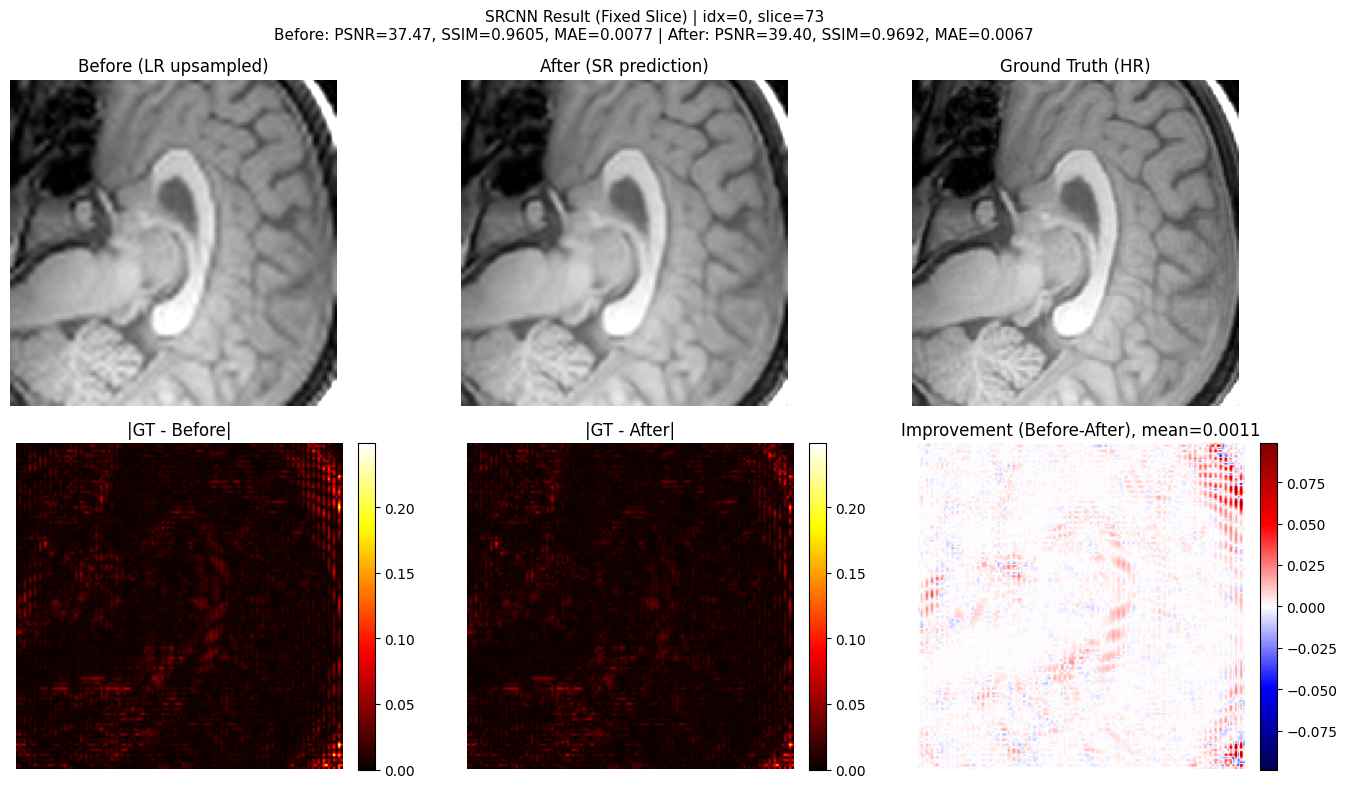

Sample path: C:/Deep learning/Final Project/IXI-T1\IXI337-IOP-0929-T1.nii.gz
Metric deltas: dPSNR=1.934, dSSIM=0.0087, dMAE=0.0011
Mean abs error: before=0.0077, after=0.0067


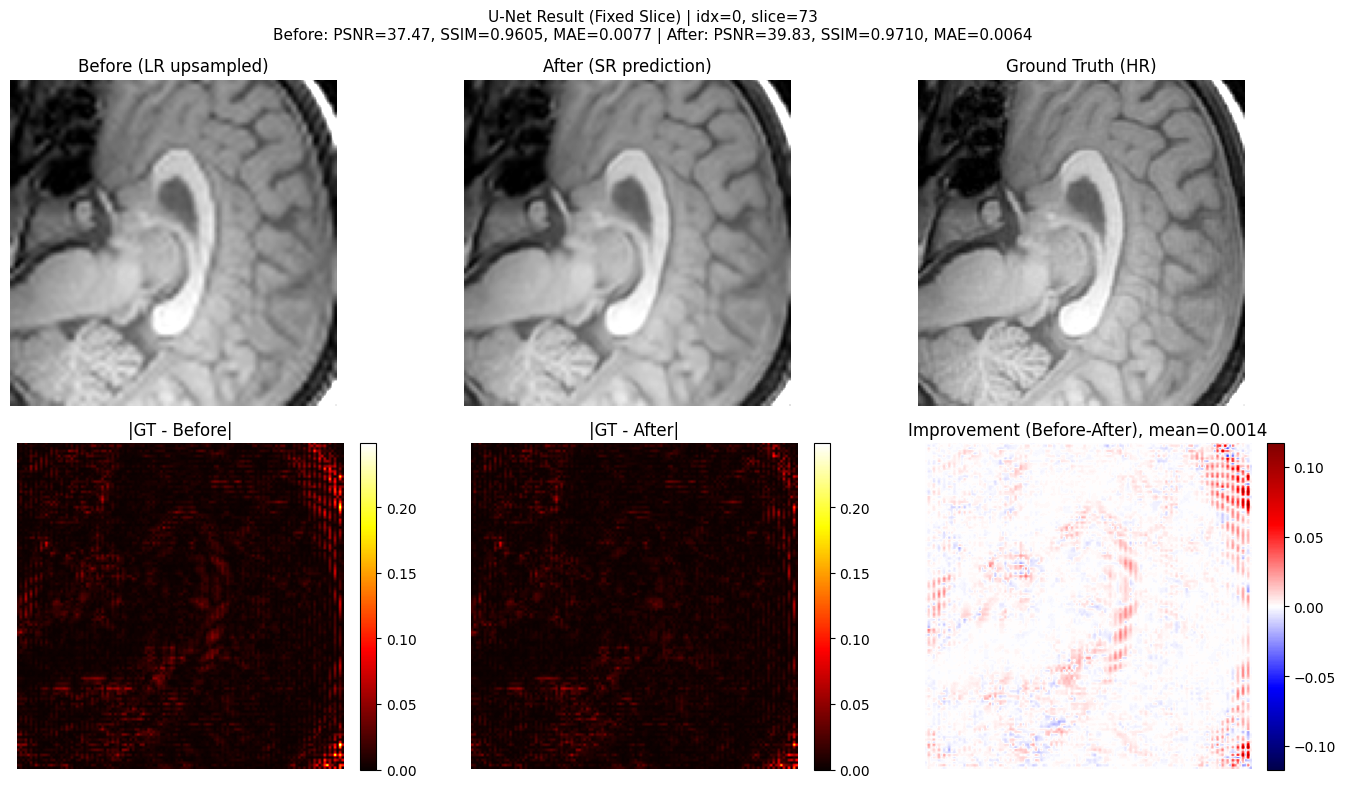

Sample path: C:/Deep learning/Final Project/IXI-T1\IXI337-IOP-0929-T1.nii.gz
Metric deltas: dPSNR=2.369, dSSIM=0.0104, dMAE=0.0014
Mean abs error: before=0.0077, after=0.0064

SRCNN fixed-set evaluation:
Fixed-set summary (n=64)
  mean dPSNR: 0.8336 | improved cases: 100.0%
  mean dSSIM: 0.01263 | improved cases: 100.0%
  mean dMAE : 0.00197 | improved cases: 100.0%

UNet fixed-set evaluation:
Fixed-set summary (n=64)
  mean dPSNR: 1.0922 | improved cases: 100.0%
  mean dSSIM: 0.01629 | improved cases: 100.0%
  mean dMAE : 0.00263 | improved cases: 100.0%

Plotting UNet best and worst by dMAE on fixed set...


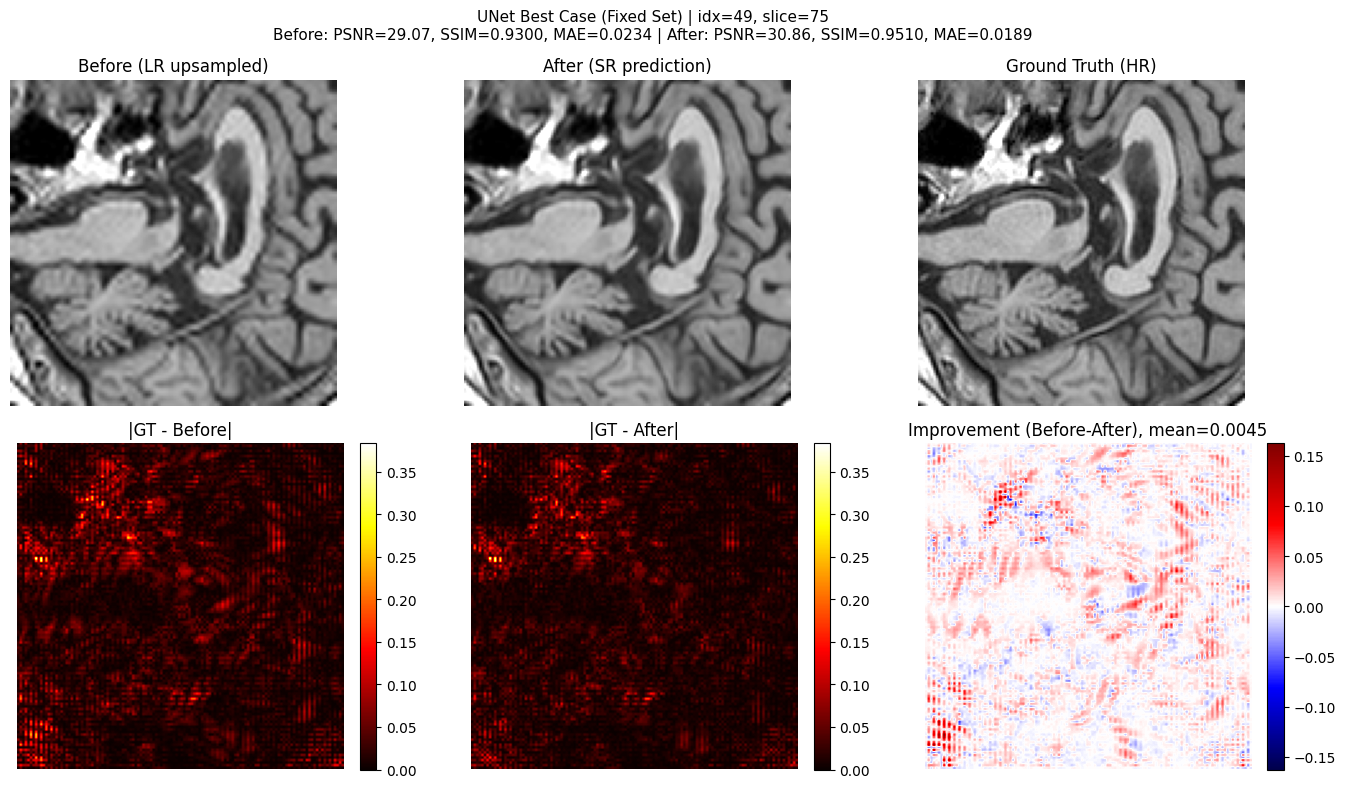

Sample path: C:/Deep learning/Final Project/IXI-T1\IXI576-Guys-1077-T1.nii.gz
Metric deltas: dPSNR=1.788, dSSIM=0.0210, dMAE=0.0045
Mean abs error: before=0.0234, after=0.0189


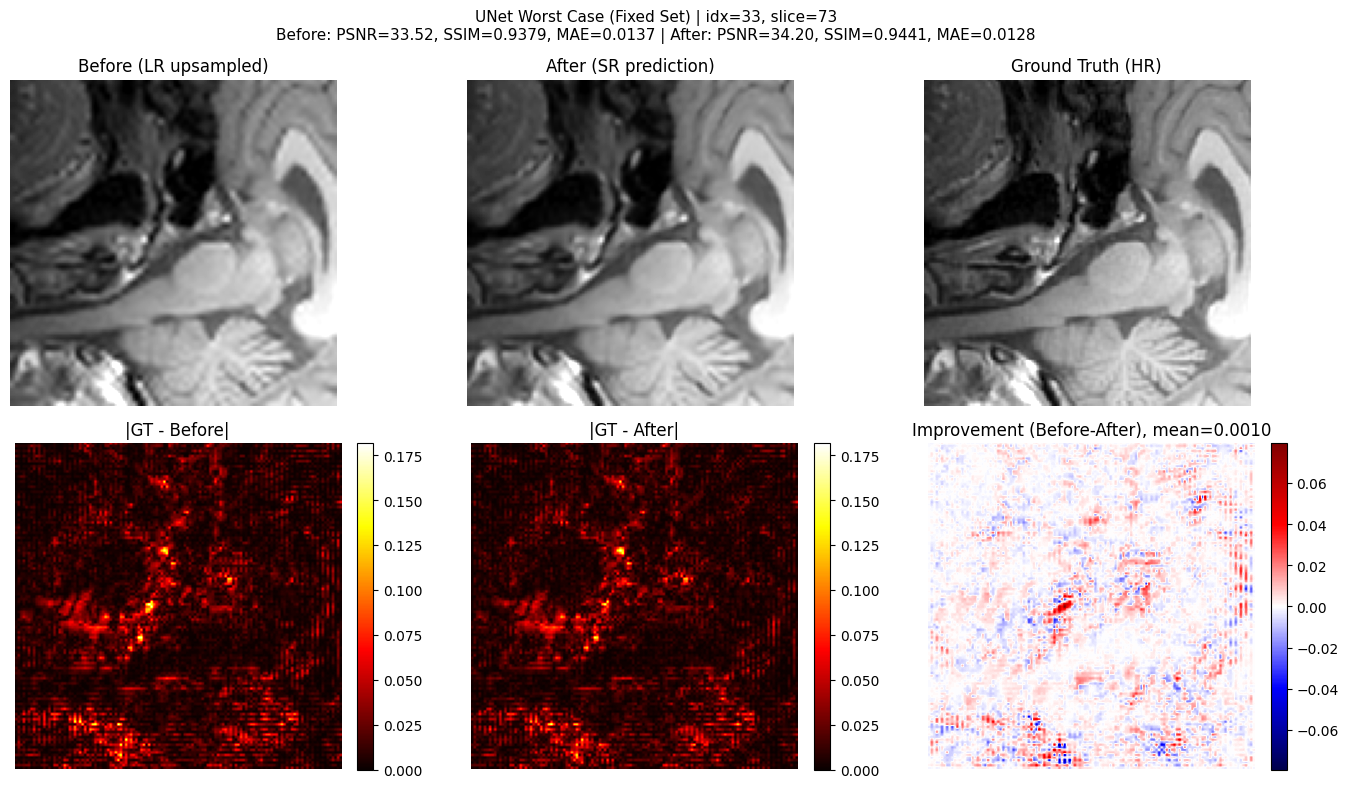

Sample path: C:/Deep learning/Final Project/IXI-T1\IXI424-IOP-0991-T1.nii.gz
Metric deltas: dPSNR=0.676, dSSIM=0.0062, dMAE=0.0010
Mean abs error: before=0.0137, after=0.0128


In [7]:
def _fixed_sample_from_dataset(dataset, idx=0, slice_index='center'):
    path = dataset.paths[idx]
    vol = nib.load(path).get_fdata()
    vol = normalize_volume(vol, method=dataset.normalize)

    axis = dataset.slice_axis
    if slice_index == 'center':
        k = vol.shape[axis] // 2
    else:
        k = int(slice_index)
        k = max(0, min(k, vol.shape[axis] - 1))

    hr = np.take(vol, k, axis=axis)
    hr = center_crop_or_pad_2d(hr, target_hw=dataset.target_hw)
    lr = make_low_res(hr, scale=dataset.scale)
    return lr.astype(np.float32), hr.astype(np.float32), path, k

def _norm_with_gt_range(arr, gt):
    mn = float(gt.min())
    mx = float(gt.max())
    return (arr - mn) / (mx - mn + 1e-8)

@torch.no_grad()
def plot_sr_example_fixed(model, dataset, idx=0, slice_index='center', title='SR Example'):
    model.eval()
    lr_np, hr_np, path, k = _fixed_sample_from_dataset(dataset, idx=idx, slice_index=slice_index)

    device = next(model.parameters()).device
    lr_t = torch.from_numpy(lr_np).unsqueeze(0).unsqueeze(0).to(device)  # [1,1,H,W]
    sr_np = model(lr_t)[0, 0].detach().cpu().numpy().astype(np.float32)

    # Fair normalization for metrics/display: use GT min/max for all three.
    lr_n = np.clip(_norm_with_gt_range(lr_np, hr_np), 0.0, 1.0)
    sr_n = np.clip(_norm_with_gt_range(sr_np, hr_np), 0.0, 1.0)
    hr_n = np.clip(_norm_with_gt_range(hr_np, hr_np), 0.0, 1.0)

    psnr_before = peak_signal_noise_ratio(hr_n, lr_n, data_range=1.0)
    ssim_before = structural_similarity(hr_n, lr_n, data_range=1.0)
    mae_before = float(np.mean(np.abs(hr_n - lr_n)))

    psnr_after = peak_signal_noise_ratio(hr_n, sr_n, data_range=1.0)
    ssim_after = structural_similarity(hr_n, sr_n, data_range=1.0)
    mae_after = float(np.mean(np.abs(hr_n - sr_n)))

    diff_before = np.abs(hr_n - lr_n)
    diff_after = np.abs(hr_n - sr_n)
    improve = diff_before - diff_after
    improve_mean = float(np.mean(improve))

    stack = np.stack([lr_n, sr_n, hr_n], axis=0)
    vmin_img = float(np.percentile(stack, 1))
    vmax_img = float(np.percentile(stack, 99))
    vmax_diff = max(float(diff_before.max()), float(diff_after.max()))

    fig, ax = plt.subplots(2, 3, figsize=(14, 8))
    fig.suptitle(
        f"{title} | idx={idx}, slice={k}\n"
        f"Before: PSNR={psnr_before:.2f}, SSIM={ssim_before:.4f}, MAE={mae_before:.4f} | "
        f"After: PSNR={psnr_after:.2f}, SSIM={ssim_after:.4f}, MAE={mae_after:.4f}",
        fontsize=11
    )

    ax[0, 0].imshow(lr_n, cmap='gray', vmin=vmin_img, vmax=vmax_img)
    ax[0, 0].set_title('Before (LR upsampled)')
    ax[0, 0].axis('off')

    ax[0, 1].imshow(sr_n, cmap='gray', vmin=vmin_img, vmax=vmax_img)
    ax[0, 1].set_title('After (SR prediction)')
    ax[0, 1].axis('off')

    ax[0, 2].imshow(hr_n, cmap='gray', vmin=vmin_img, vmax=vmax_img)
    ax[0, 2].set_title('Ground Truth (HR)')
    ax[0, 2].axis('off')

    im1 = ax[1, 0].imshow(diff_before, cmap='hot', vmin=0, vmax=vmax_diff)
    ax[1, 0].set_title('|GT - Before|')
    ax[1, 0].axis('off')
    plt.colorbar(im1, ax=ax[1, 0], fraction=0.046, pad=0.04)

    im2 = ax[1, 1].imshow(diff_after, cmap='hot', vmin=0, vmax=vmax_diff)
    ax[1, 1].set_title('|GT - After|')
    ax[1, 1].axis('off')
    plt.colorbar(im2, ax=ax[1, 1], fraction=0.046, pad=0.04)

    from matplotlib.colors import TwoSlopeNorm
    vlim = max(float(np.max(np.abs(improve))), 1e-8)
    im3 = ax[1, 2].imshow(improve, cmap='seismic', norm=TwoSlopeNorm(vcenter=0.0, vmin=-vlim, vmax=vlim))
    ax[1, 2].set_title(f'Improvement (Before-After), mean={improve_mean:.4f}')
    ax[1, 2].axis('off')
    plt.colorbar(im3, ax=ax[1, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
    print('Sample path:', path)
    print(f'Metric deltas: dPSNR={psnr_after-psnr_before:.3f}, dSSIM={ssim_after-ssim_before:.4f}, dMAE={mae_before-mae_after:.4f}')
    print(f'Mean abs error: before={float(np.mean(diff_before)):.4f}, after={float(np.mean(diff_after)):.4f}')

plot_sr_example_fixed(srcnn, val_ds, idx=0, slice_index='center', title='SRCNN Result (Fixed Slice)')
plot_sr_example_fixed(unet, val_ds, idx=0, slice_index='center', title='U-Net Result (Fixed Slice)')

@torch.no_grad()
def evaluate_model_fixed_set(model, dataset, n_samples=64, slice_index='center'):
    model.eval()
    device = next(model.parameters()).device
    n = min(n_samples, len(dataset.paths))

    dpsnr_list, dssim_list, dmae_list = [], [], []
    for i in range(n):
        lr_np, hr_np, _, _ = _fixed_sample_from_dataset(dataset, idx=i, slice_index=slice_index)
        lr_t = torch.from_numpy(lr_np).unsqueeze(0).unsqueeze(0).to(device)
        sr_np = model(lr_t)[0, 0].detach().cpu().numpy().astype(np.float32)

        lr_n = np.clip(_norm_with_gt_range(lr_np, hr_np), 0.0, 1.0)
        sr_n = np.clip(_norm_with_gt_range(sr_np, hr_np), 0.0, 1.0)
        hr_n = np.clip(_norm_with_gt_range(hr_np, hr_np), 0.0, 1.0)

        psnr_before = peak_signal_noise_ratio(hr_n, lr_n, data_range=1.0)
        ssim_before = structural_similarity(hr_n, lr_n, data_range=1.0)
        mae_before = float(np.mean(np.abs(hr_n - lr_n)))

        psnr_after = peak_signal_noise_ratio(hr_n, sr_n, data_range=1.0)
        ssim_after = structural_similarity(hr_n, sr_n, data_range=1.0)
        mae_after = float(np.mean(np.abs(hr_n - sr_n)))

        dpsnr_list.append(psnr_after - psnr_before)
        dssim_list.append(ssim_after - ssim_before)
        dmae_list.append(mae_before - mae_after)

    dpsnr = np.array(dpsnr_list)
    dssim = np.array(dssim_list)
    dmae = np.array(dmae_list)

    print(f'Fixed-set summary (n={n})')
    print(f'  mean dPSNR: {dpsnr.mean():.4f} | improved cases: {(dpsnr > 0).mean()*100:.1f}%')
    print(f'  mean dSSIM: {dssim.mean():.5f} | improved cases: {(dssim > 0).mean()*100:.1f}%')
    print(f'  mean dMAE : {dmae.mean():.5f} | improved cases: {(dmae > 0).mean()*100:.1f}%')

    best_idx = int(np.argmax(dmae))
    worst_idx = int(np.argmin(dmae))
    return {'best_idx': best_idx, 'worst_idx': worst_idx, 'dpsnr': dpsnr, 'dssim': dssim, 'dmae': dmae}

print('\nSRCNN fixed-set evaluation:')
srcnn_stats = evaluate_model_fixed_set(srcnn, val_ds, n_samples=64, slice_index='center')
print('\nUNet fixed-set evaluation:')
unet_stats = evaluate_model_fixed_set(unet, val_ds, n_samples=64, slice_index='center')

print('\nPlotting UNet best and worst by dMAE on fixed set...')
plot_sr_example_fixed(unet, val_ds, idx=unet_stats['best_idx'], slice_index='center', title='UNet Best Case (Fixed Set)')
plot_sr_example_fixed(unet, val_ds, idx=unet_stats['worst_idx'], slice_index='center', title='UNet Worst Case (Fixed Set)')


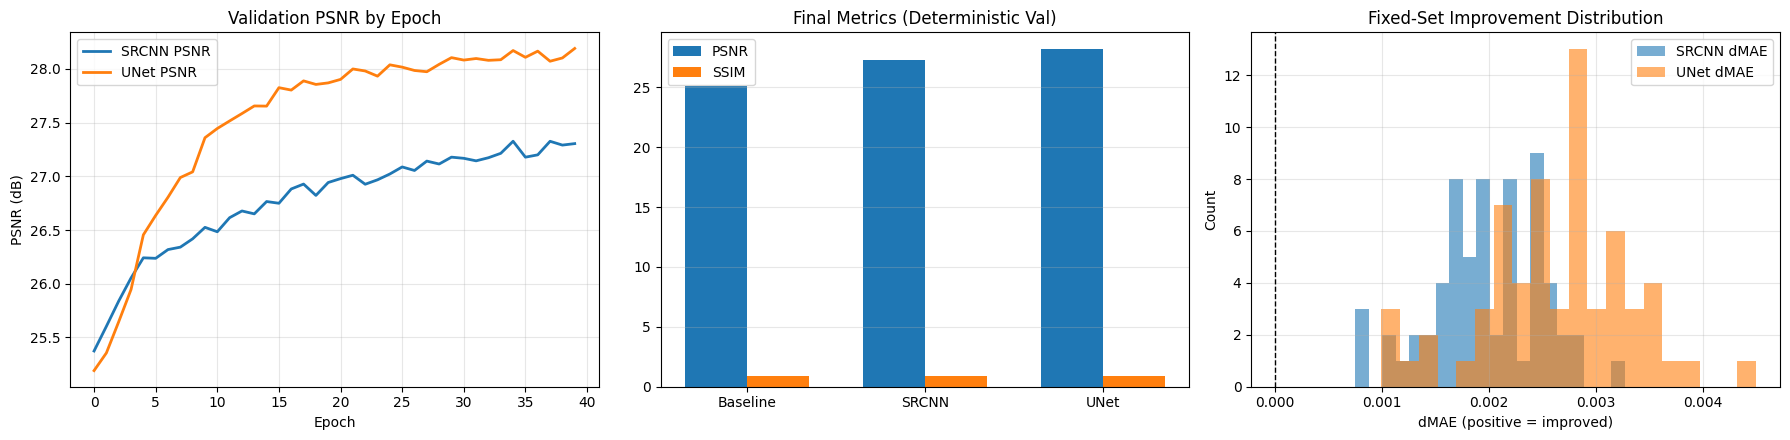

Summary:
Baseline -> PSNR=25.138, SSIM=0.8929
SRCNN   -> PSNR=27.304, SSIM=0.9184
UNet    -> PSNR=28.190, SSIM=0.9261
SRCNN improvement rate (dMAE>0): 100.0%
UNet improvement rate  (dMAE>0): 100.0%


In [8]:
# Results dashboard graphs (for report-quality visuals)
import numpy as np
import matplotlib.pyplot as plt

# Required variables from previous cells:
# hist_srcnn, hist_unet, base_psnr, base_ssim, srcnn_stats, unet_stats

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))

# 1) Validation curves across epochs
ax[0].plot(hist_srcnn['val_psnr'], label='SRCNN PSNR', linewidth=2)
ax[0].plot(hist_unet['val_psnr'], label='UNet PSNR', linewidth=2)
ax[0].set_title('Validation PSNR by Epoch')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('PSNR (dB)')
ax[0].grid(alpha=0.3)
ax[0].legend()

# 2) Final metric comparison bar chart (vs baseline)
labels = ['Baseline', 'SRCNN', 'UNet']
psnr_vals = [base_psnr, hist_srcnn['val_psnr'][-1], hist_unet['val_psnr'][-1]]
ssim_vals = [base_ssim, hist_srcnn['val_ssim'][-1], hist_unet['val_ssim'][-1]]

x = np.arange(len(labels))
width = 0.35
ax[1].bar(x - width/2, psnr_vals, width, label='PSNR')
ax[1].bar(x + width/2, ssim_vals, width, label='SSIM')
ax[1].set_xticks(x)
ax[1].set_xticklabels(labels)
ax[1].set_title('Final Metrics (Deterministic Val)')
ax[1].grid(axis='y', alpha=0.3)
ax[1].legend()

# 3) Improvement distribution (dMAE) on fixed set
ax[2].hist(srcnn_stats['dmae'], bins=20, alpha=0.6, label='SRCNN dMAE')
ax[2].hist(unet_stats['dmae'], bins=20, alpha=0.6, label='UNet dMAE')
ax[2].axvline(0, color='black', linestyle='--', linewidth=1)
ax[2].set_title('Fixed-Set Improvement Distribution')
ax[2].set_xlabel('dMAE (positive = improved)')
ax[2].set_ylabel('Count')
ax[2].grid(alpha=0.3)
ax[2].legend()

plt.tight_layout()
plt.show()

# Optional: quick text summary for report
print('Summary:')
print(f"Baseline -> PSNR={base_psnr:.3f}, SSIM={base_ssim:.4f}")
print(f"SRCNN   -> PSNR={hist_srcnn['val_psnr'][-1]:.3f}, SSIM={hist_srcnn['val_ssim'][-1]:.4f}")
print(f"UNet    -> PSNR={hist_unet['val_psnr'][-1]:.3f}, SSIM={hist_unet['val_ssim'][-1]:.4f}")
print(f"SRCNN improvement rate (dMAE>0): {(srcnn_stats['dmae']>0).mean()*100:.1f}%")
print(f"UNet improvement rate  (dMAE>0): {(unet_stats['dmae']>0).mean()*100:.1f}%")



In [ ]:
# Advanced SR training/evaluation block
# Includes: early stopping, perceptual loss (bonus), noise robustness (bonus),
# loss curves, side-by-side visuals, quantitative PSNR/SSIM tables, and error analysis.

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import scipy.ndimage as ndi


def fixed_hr_from_dataset(dataset, idx=0, slice_index='center'):
    path = dataset.paths[idx]
    vol = nib.load(path).get_fdata()
    vol = normalize_volume(vol, method=dataset.normalize)

    axis = dataset.slice_axis
    if slice_index == 'center':
        k = vol.shape[axis] // 2
    else:
        k = int(slice_index)
        k = max(0, min(k, vol.shape[axis] - 1))

    hr = np.take(vol, k, axis=axis)
    hr = center_crop_or_pad_2d(hr, target_hw=dataset.target_hw).astype(np.float32)
    return hr, path, k


def make_lr_small_and_bicubic(hr, scale=2):
    lr_small = ndi.zoom(hr, zoom=(1/scale, 1/scale), order=3).astype(np.float32)
    bicubic = ndi.zoom(lr_small, zoom=(scale, scale), order=3).astype(np.float32)
    bicubic = bicubic[:hr.shape[0], :hr.shape[1]]
    return lr_small, bicubic


def to_01(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)


# -----------------------------
# Bonus: noise robustness
# -----------------------------
def add_noise(img, noise_type='gaussian', sigma=0.02):
    # img expected in [0,1]
    if sigma <= 0:
        return img
    if noise_type == 'gaussian':
        n = np.random.normal(0.0, sigma, img.shape).astype(np.float32)
        out = img + n
    elif noise_type == 'rician':
        n1 = np.random.normal(0.0, sigma, img.shape).astype(np.float32)
        n2 = np.random.normal(0.0, sigma, img.shape).astype(np.float32)
        out = np.sqrt((img + n1) ** 2 + n2 ** 2)
    else:
        raise ValueError("noise_type must be 'gaussian' or 'rician'")
    return np.clip(out, 0.0, 1.0)


class NoisyWrapperDataset(Dataset):
    def __init__(self, base_ds, noise_type='gaussian', sigma=0.02, enabled=True):
        self.base_ds = base_ds
        self.noise_type = noise_type
        self.sigma = sigma
        self.enabled = enabled

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        lr = item['lr'].numpy().astype(np.float32)   # [1,H,W]
        hr = item['hr'].numpy().astype(np.float32)   # [1,H,W]

        # Normalize to [0,1] using HR range for fair noise injection
        hr2d = hr[0]
        lr2d = lr[0]

        mn, mx = hr2d.min(), hr2d.max()
        hr01 = (hr2d - mn) / (mx - mn + 1e-8)
        lr01 = (lr2d - mn) / (mx - mn + 1e-8)
        lr01 = np.clip(lr01, 0.0, 1.0)


        if self.enabled:
            lr01 = add_noise(lr01, noise_type=self.noise_type, sigma=self.sigma)

        return {
            'lr': torch.from_numpy(lr01[None, ...]),
            'hr': torch.from_numpy(hr01[None, ...]),
            'path': item['path']
        }


# -----------------------------
# Bonus: perceptual loss (VGG)
# -----------------------------
class PerceptualLossVGG(nn.Module):
    def __init__(self, device='cpu'):
        super().__init__()
        self.available = False
        try:
            from torchvision.models import vgg16, VGG16_Weights
            weights = VGG16_Weights.IMAGENET1K_V1
            vgg = vgg16(weights=weights).features[:16].eval()  # up to relu3_3-ish
            for p in vgg.parameters():
                p.requires_grad = False
            self.vgg = vgg.to(device)
            self.available = True
            self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
            self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))
        except Exception as e:
            print('[PerceptualLossVGG] torchvision/VGG unavailable. Falling back to pixel-only loss.')
            self.vgg = None

    def forward(self, pred, target):
        if not self.available:
            return pred.new_tensor(0.0)

        # pred/target: [B,1,H,W] in [0,1]
        pred3 = pred.repeat(1, 3, 1, 1)
        tgt3 = target.repeat(1, 3, 1, 1)

        pred3 = (pred3 - self.mean) / self.std
        tgt3 = (tgt3 - self.mean) / self.std

        fp = self.vgg(pred3)
        ft = self.vgg(tgt3)
        return F.l1_loss(fp, ft)


# -----------------------------
# Early stopping training
# -----------------------------
@torch.no_grad()
def evaluate_loader(model, loader, device):
    model.eval()
    psnr_vals, ssim_vals, l1_vals = [], [], []
    for batch in loader:
        lr = batch['lr'].to(device)
        hr = batch['hr'].to(device)
        sr = model(lr)

        l1_vals.append(F.l1_loss(sr, hr).item())

        sr_np = sr.detach().cpu().numpy()
        hr_np = hr.detach().cpu().numpy()
        for i in range(sr_np.shape[0]):
            pred = np.clip(sr_np[i,0], 0.0, 1.0)
            gt = np.clip(hr_np[i,0], 0.0, 1.0)
            psnr_vals.append(peak_signal_noise_ratio(gt, pred, data_range=1.0))
            ssim_vals.append(structural_similarity(gt, pred, data_range=1.0))

    return {
        'val_l1': float(np.mean(l1_vals)),
        'val_psnr': float(np.mean(psnr_vals)),
        'val_ssim': float(np.mean(ssim_vals)),
    }


def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    device,
    max_epochs=30,
    lr=5e-5,
    lambda_perc=0.05,
    use_perceptual=True,
    early_stop_patience=6,
    min_delta=1e-4,
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3, min_lr=1e-6
    )

    perc_loss = PerceptualLossVGG(device=device) if use_perceptual else None

    best_score = -np.inf
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    hist = {
        'train_total': [],
        'train_l1': [],
        'train_perc': [],
        'val_l1': [],
        'val_psnr': [],
        'val_ssim': [],
        'lr': [],
    }

    for ep in range(1, max_epochs + 1):
        model.train()
        run_total, run_l1, run_perc = 0.0, 0.0, 0.0

        for batch in train_loader:
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)

            optimizer.zero_grad()
            sr_img = model(lr_img)

            l1 = F.l1_loss(sr_img, hr_img)
            if perc_loss is not None:
                pl = perc_loss(sr_img, hr_img)
            else:
                pl = l1.new_tensor(0.0)

            loss = l1 + lambda_perc * pl
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            run_total += loss.item()
            run_l1 += l1.item()
            run_perc += pl.item()

        n_batches = max(1, len(train_loader))
        train_total = run_total / n_batches
        train_l1 = run_l1 / n_batches
        train_perc = run_perc / n_batches

        val = evaluate_loader(model, val_loader, device)
        scheduler.step(val['val_psnr'])

        cur_lr = optimizer.param_groups[0]['lr']
        hist['train_total'].append(train_total)
        hist['train_l1'].append(train_l1)
        hist['train_perc'].append(train_perc)
        hist['val_l1'].append(val['val_l1'])
        hist['val_psnr'].append(val['val_psnr'])
        hist['val_ssim'].append(val['val_ssim'])
        hist['lr'].append(cur_lr)

        print(
            f"Epoch {ep:02d} | lr={cur_lr:.2e} | train_total={train_total:.4f} | "
            f"train_l1={train_l1:.4f} | train_perc={train_perc:.4f} | "
            f"val_l1={val['val_l1']:.4f} | val_psnr={val['val_psnr']:.3f} | val_ssim={val['val_ssim']:.4f}"
        )

        score = val['val_psnr']
        if score > best_score + min_delta:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {ep} (no val PSNR improvement for {early_stop_patience} epochs).")
            break

    model.load_state_dict(best_state)
    return model, hist


# -----------------------------
# Required outputs
# -----------------------------
def plot_loss_curves(hist, title='Loss Curves'):
    epochs = np.arange(1, len(hist['train_total']) + 1)
    plt.figure(figsize=(10,4))
    plt.plot(epochs, hist['train_total'], label='Train Total Loss', linewidth=2)
    plt.plot(epochs, hist['train_l1'], label='Train L1 Loss', linewidth=2)
    plt.plot(epochs, hist['val_l1'], label='Validation L1 Loss', linewidth=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def side_by_side_visual(model, dataset, idx=0, scale=2, title='Visual Comparison'):
    model.eval()
    hr, path, k = fixed_hr_from_dataset(dataset, idx=idx, slice_index='center')
    lr_small, bicubic = make_lr_small_and_bicubic(hr, scale=scale)

    # model input is bicubic (upsampled LR)
    inp = torch.from_numpy(to_01(bicubic)[None,None,...]).float().to(next(model.parameters()).device)
    with torch.no_grad():
        pred = model(inp)[0,0].detach().cpu().numpy()

    hr01 = to_01(hr)
    bic01 = to_01(bicubic)
    pred01 = np.clip(pred, 0.0, 1.0)

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"{title} | idx={idx}, slice={k}")

    ax[0].imshow(lr_small, cmap='gray')
    ax[0].set_title('Low-Resolution Input')
    ax[0].axis('off')

    ax[1].imshow(bic01, cmap='gray')
    ax[1].set_title('Bicubic Upsampling')
    ax[1].axis('off')

    ax[2].imshow(pred01, cmap='gray')
    ax[2].set_title('Model Prediction')
    ax[2].axis('off')

    ax[3].imshow(hr01, cmap='gray')
    ax[3].set_title('High-Resolution Ground Truth')
    ax[3].axis('off')

    plt.tight_layout()
    plt.show()

    print('Sample path:', path)


@torch.no_grad()
def quantitative_test_table(model, dataset, n_samples=64, scale=2):
    device = next(model.parameters()).device
    model.eval()

    rows = []
    n = min(n_samples, len(dataset.paths))

    for i in range(n):
        hr, path, k = fixed_hr_from_dataset(dataset, idx=i, slice_index='center')
        lr_small, bicubic = make_lr_small_and_bicubic(hr, scale=scale)

        hr01 = to_01(hr)
        bic01 = to_01(bicubic)

        inp = torch.from_numpy(bic01[None,None,...]).float().to(device)
        pred01 = model(inp)[0,0].detach().cpu().numpy()
        pred01 = np.clip(pred01, 0.0, 1.0)

        row = {
            'idx': i,
            'path': path,
            'slice': k,
            'psnr_bicubic': peak_signal_noise_ratio(hr01, bic01, data_range=1.0),
            'ssim_bicubic': structural_similarity(hr01, bic01, data_range=1.0),
            'psnr_model': peak_signal_noise_ratio(hr01, pred01, data_range=1.0),
            'ssim_model': structural_similarity(hr01, pred01, data_range=1.0),
            'mae_bicubic': float(np.mean(np.abs(hr01 - bic01))),
            'mae_model': float(np.mean(np.abs(hr01 - pred01))),
        }
        row['d_psnr'] = row['psnr_model'] - row['psnr_bicubic']
        row['d_ssim'] = row['ssim_model'] - row['ssim_bicubic']
        row['d_mae'] = row['mae_bicubic'] - row['mae_model']
        rows.append(row)

    df = pd.DataFrame(rows)

    summary = pd.DataFrame({
        'metric': ['PSNR', 'SSIM', 'MAE'],
        'bicubic_mean': [df['psnr_bicubic'].mean(), df['ssim_bicubic'].mean(), df['mae_bicubic'].mean()],
        'model_mean': [df['psnr_model'].mean(), df['ssim_model'].mean(), df['mae_model'].mean()],
        'delta_mean': [df['d_psnr'].mean(), df['d_ssim'].mean(), df['d_mae'].mean()],
        'improved_cases_%': [
            (df['d_psnr'] > 0).mean() * 100,
            (df['d_ssim'] > 0).mean() * 100,
            (df['d_mae'] > 0).mean() * 100,
        ]
    })

    return df, summary


def error_analysis(model, dataset, test_df, top_k=3, scale=2):
    # Analyze worst dMAE slices (model worse than bicubic)
    worst = test_df.sort_values('d_mae').head(top_k)
    print('Worst cases by dMAE (negative means model is worse):')
    display(worst[['idx','slice','d_mae','d_psnr','d_ssim','path']])

    device = next(model.parameters()).device
    model.eval()

    for _, r in worst.iterrows():
        idx = int(r['idx'])
        hr, path, k = fixed_hr_from_dataset(dataset, idx=idx, slice_index='center')
        _, bicubic = make_lr_small_and_bicubic(hr, scale=scale)

        hr01 = to_01(hr)
        bic01 = to_01(bicubic)

        inp = torch.from_numpy(bic01[None,None,...]).float().to(device)
        with torch.no_grad():
            pred01 = model(inp)[0,0].detach().cpu().numpy()
        pred01 = np.clip(pred01, 0.0, 1.0)

        # Edge-focused error to inspect fine structures/textures
        edge_hr = np.hypot(ndi.sobel(hr01, axis=0), ndi.sobel(hr01, axis=1))
        edge_bic = np.hypot(ndi.sobel(bic01, axis=0), ndi.sobel(bic01, axis=1))
        edge_pred = np.hypot(ndi.sobel(pred01, axis=0), ndi.sobel(pred01, axis=1))

        edge_err_bic = np.abs(edge_hr - edge_bic)
        edge_err_pred = np.abs(edge_hr - edge_pred)

        fig, ax = plt.subplots(2, 3, figsize=(13, 8))
        fig.suptitle(f"Failure Analysis | idx={idx}, slice={k}")

        ax[0,0].imshow(hr01, cmap='gray'); ax[0,0].set_title('Ground Truth'); ax[0,0].axis('off')
        ax[0,1].imshow(bic01, cmap='gray'); ax[0,1].set_title('Bicubic'); ax[0,1].axis('off')
        ax[0,2].imshow(pred01, cmap='gray'); ax[0,2].set_title('Model Prediction'); ax[0,2].axis('off')

        ax[1,0].imshow(np.abs(hr01-bic01), cmap='hot'); ax[1,0].set_title('|GT-Bicubic|'); ax[1,0].axis('off')
        ax[1,1].imshow(np.abs(hr01-pred01), cmap='hot'); ax[1,1].set_title('|GT-Pred|'); ax[1,1].axis('off')
        ax[1,2].imshow(edge_err_pred-edge_err_bic, cmap='bwr'); ax[1,2].set_title('Edge Error Delta'); ax[1,2].axis('off')

        plt.tight_layout()
        plt.show()

        print('Path:', path)
        print(
            'Interpretation hint: high edge-error regions suggest missed fine anatomical boundaries '
            '(e.g., thin vessels/cortical edges) or hallucinated textures in smooth tissue regions.'
        )



device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Train with noise robustness on train set, keep deterministic val set
train_noisy = NoisyWrapperDataset(train_ds, noise_type='rician', sigma=0.02, enabled=True)
val_clean = NoisyWrapperDataset(val_ds, noise_type='gaussian', sigma=0.0, enabled=False)

train_loader_adv = DataLoader(train_noisy, batch_size=4, shuffle=True, num_workers=0)
val_loader_adv = DataLoader(val_clean, batch_size=4, shuffle=False, num_workers=0)

# You can switch to SRCNN2D() if you want baseline training here
model_adv = UNet2DSR(base=32)

model_adv, hist_adv = train_with_early_stopping(
    model=model_adv,
    train_loader=train_loader_adv,
    val_loader=val_loader_adv,
    device=device,
    max_epochs=30,
    lr=5e-5,
    lambda_perc=0.05,
    use_perceptual=True,
    early_stop_patience=6,
)

#training/validation loss curves
plot_loss_curves(hist_adv, title='UNet2DSR Training/Validation Loss (with Early Stopping)')

# side-by-side visual comparisons
side_by_side_visual(model_adv, val_ds, idx=0, scale=2, title='Side-by-Side SR Comparison')

# quantitative PSNR/SSIM tables on test set (using val_ds as deterministic test split)
test_df, summary_df = quantitative_test_table(model_adv, val_ds, n_samples=64, scale=2)
print('Quantitative summary across test set:')
display(summary_df)
print('Per-case table (first 10 rows):')
display(test_df.head(10))

#  error analysis of failure cases
error_analysis(model_adv, val_ds, test_df, top_k=3, scale=2)



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\aliat/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|██████████| 528M/528M [02:36<00:00, 3.55MB/s] 


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!